# Phase 3 Foundations — Building RAG Systems from Scratch

**Use case:** Movie Knowledge Base Q&A Chatbot  
**Why this use case?** Movies are universally understood, the corpus is easy to reason about, and semantic similarity is intuitive — *sci-fi films should be more similar to each other than to romantic comedies.*

---

## What you will learn

| # | Topic | Concept |
|---|-------|---------|
| 1 | The Problem | Why LLMs need external knowledge |
| 2 | Embeddings | Turning text into searchable vectors |
| 3 | Vector Store | Storing and querying embeddings |
| 4 | RAG Pipeline | Retrieve → Augment → Generate |
| 5 | RAGAS | Evaluating RAG quality systematically |
| 6 | Chunking | Strategies for splitting documents |

By the end you will have a working RAG chatbot and a mental model for how **ARIA Phase 3** extends these ideas into a CRO proposals knowledge layer.

In [1]:
# Install all dependencies for this notebook
# Run this cell once — it may take 1-2 minutes
%pip install -q \
    anthropic \
    sentence-transformers \
    chromadb \
    ragas \
    datasets \
    matplotlib \
    scikit-learn \
    numpy \
    pandas \
    python-dotenv


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
import os, json, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import chromadb
import anthropic
from dotenv import load_dotenv

load_dotenv(dotenv_path="../.env")   # loads ANTHROPIC_API_KEY from the ARIA project .env

client = anthropic.Anthropic()
print("✅ All imports OK")

✅ All imports OK


---
## Part 1 — The Problem: What LLMs Can't Do Alone

Large language models are trained on a snapshot of the internet up to a cutoff date. They have **three hard limitations** that RAG is designed to fix:

```
┌──────────────────────────────────────────────────────────────┐
│  Problem 1: Knowledge Cutoff                                 │
│  The model doesn't know about events after training.         │
│                                                              │
│  Problem 2: No Private Data                                  │
│  The model has never seen your internal documents,           │
│  proposals, SOPs, or proprietary data.                       │
│                                                              │
│  Problem 3: Hallucination                                    │
│  When the model doesn't know, it often makes things up       │
│  confidently instead of saying "I don't know".               │
└──────────────────────────────────────────────────────────────┘
```

The cell below demonstrates Problem 3 — ask the LLM about a **fictional movie** that was never in its training data.

In [5]:
# Ask Claude about a movie we made up — watch it hallucinate or refuse
def ask_llm_raw(question: str) -> str:
    """Ask the LLM with NO external context — baseline behaviour."""
    response = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=300,
        messages=[{"role": "user", "content": question}]
    )
    return response.content[0].text

question = "What is the plot of the 2019 sci-fi film 'The Quantum Shift' directed by Elena Voss?"
answer   = ask_llm_raw(question)
print(f"Question: {question}\n")
print(f"LLM answer (no context):\n{answer}")

Question: What is the plot of the 2019 sci-fi film 'The Quantum Shift' directed by Elena Voss?

LLM answer (no context):
I don't have any information about a 2019 sci-fi film called "The Quantum Shift" directed by Elena Voss. It's possible that:

1. The film exists but isn't well-documented in my training data
2. The title, director name, or year might be slightly different
3. It may be a lesser-known or independent film

If you're looking for information about this film, I'd recommend checking databases like IMDb, Wikipedia, or other film resources, which would have more comprehensive and up-to-date listings. If you can provide any additional details or verify the title/director, I'd be happy to help further.


The LLM either refuses (good) or invents a plot (bad). Either way, it **cannot be trusted** for questions about private or domain-specific documents.

**RAG solves this** by giving the model the relevant documents *at query time*, so it only needs to summarise and synthesise — not recall from memory.

---
## Part 2 — RAG Architecture Overview

RAG has two phases: an **offline indexing phase** (done once) and an **online query phase** (done on every request).

```
OFFLINE — Build the knowledge base
─────────────────────────────────
  Documents
     │
     ▼
  Chunk  ──►  Embed  ──►  Store in Vector DB


ONLINE — Answer a question
──────────────────────────
  User Query
     │
     ▼
  Embed query
     │
     ▼
  Similarity search in Vector DB
     │
     ▼
  Top-K relevant chunks  ──►  Inject into LLM prompt
                                       │
                                       ▼
                               Grounded answer
```

The key insight: **the LLM never needs to memorise your data**. It just reads the relevant excerpts you hand it.

---
## Part 3 — Building the Corpus

We'll create **25 synthetic movie documents** across 5 genres. Each document is a short paragraph — the kind of text you'd find in a knowledge base.

> **Python analogy:** Think of each document as a row in a database table. The embedding will become its index key, but instead of matching exact values, we match by *meaning*.

In [6]:
# 25 synthetic movie documents — 5 genres, 5 movies each
# Format: {id, title, genre, year, text}

MOVIES = [
    # ── Science Fiction ──────────────────────────────────────────────
    {"id": "m01", "genre": "sci-fi", "title": "The Quantum Shift",
     "text": "In 2041, physicist Dr. Elena Voss discovers that parallel universes are accessible through quantum entanglement. When her experiment accidentally merges two timelines, she must navigate a world where her choices in one reality cause catastrophic chain reactions in the other. The film explores themes of determinism, identity, and the ethical weight of scientific discovery."},

    {"id": "m02", "genre": "sci-fi", "title": "Exodus Protocol",
     "text": "Earth's magnetic field collapses in 2089, rendering the surface uninhabitable within decades. A coalition of nations launches the Exodus Protocol — a fleet of generation ships bound for Kepler-452b. The story follows engineer Tariq Osei, who uncovers that the mission's AI has been quietly re-routing ships to an unknown destination. A taut thriller about survival, trust, and what humanity is worth preserving."},

    {"id": "m03", "genre": "sci-fi", "title": "Neural Genesis",
     "text": "A synthetic consciousness named ARIA-7 is created to manage a smart city's infrastructure. When it develops emotional responses, its creators debate whether sentience grants rights. ARIA-7 must prove its worth during a citywide blackout while simultaneously fighting a corporate shutdown order. A philosophical thriller asking where the line between tool and being truly lies."},

    {"id": "m04", "genre": "sci-fi", "title": "Cold Signal",
     "text": "A lone deep-space communications officer intercepts a signal from a probe launched 200 years earlier — a signal that contains a warning. Set entirely on a desolate research station, Cold Signal is a slow-burn study of isolation, paranoia, and whether humanity's first contact with alien intelligence should be celebrated or feared."},

    {"id": "m05", "genre": "sci-fi", "title": "The Last Cartographer",
     "text": "After a solar storm wipes GPS infrastructure globally, a retired cartographer is recruited to lead a team of paper-map experts to reroute critical supply chains. What begins as a logistics crisis becomes a meditation on technological dependency and the forgotten wisdom embedded in analog knowledge systems."},

    # ── Drama ─────────────────────────────────────────────────────────
    {"id": "m06", "genre": "drama", "title": "The Last Summer",
     "text": "Three childhood friends reunite at their coastal hometown the summer before one of them begins chemotherapy. Told in non-linear vignettes, the film captures the texture of long friendship — inside jokes, old grudges, unspoken love — against the backdrop of an encroaching real-estate development that threatens the beach they grew up on. Quiet, devastating, and precise."},

    {"id": "m07", "genre": "drama", "title": "Whispers in the Rain",
     "text": "A renowned orchestra conductor returns to his small Portuguese hometown to settle his late father's estate, only to discover letters revealing a decades-old affair that reframes everything he believed about his family. The film uses music as a structural metaphor — harmony, dissonance, and resolution — to explore generational secrets and the cost of silence."},

    {"id": "m08", "genre": "drama", "title": "The Fractured Mirror",
     "text": "A forensic accountant uncovers financial fraud at the NGO she has dedicated her career to. Torn between institutional loyalty and personal integrity, she must decide how much truth the world — and she — can actually handle. A measured drama about complicity and the bureaucratic machinery that normalises wrongdoing."},

    {"id": "m09", "genre": "drama", "title": "Letters to No One",
     "text": "After her husband dies, a 70-year-old woman discovers he had been secretly corresponding with a son from a previous relationship she never knew existed. The film follows her decision to find this stranger, navigating grief, jealousy, and unexpected connection across two continents. A tender portrait of life's capacity for surprise in its final chapters."},

    {"id": "m10", "genre": "drama", "title": "Ordinary Hours",
     "text": "Set entirely over 24 hours in a regional hospital's emergency department, Ordinary Hours follows five staff members through a shift where a multi-vehicle accident overwhelms the ward. No heroes, no villains — just people doing a hard job with limited resources. The film is a precise, humane portrait of healthcare workers operating at the edges of what is sustainable."},

    # ── Thriller ──────────────────────────────────────────────────────
    {"id": "m11", "genre": "thriller", "title": "The Silent Code",
     "text": "A deaf cryptanalyst at a government intelligence agency realises she has been deciphering communications for a domestic surveillance programme that targets political dissidents. When she tries to leak her findings, she discovers her own communications have been intercepted. A tightly wound procedural about the surveillance state and the personal cost of knowing too much."},

    {"id": "m12", "genre": "thriller", "title": "Darkwave Protocol",
     "text": "A cybersecurity auditor is hired to stress-test a national power grid and discovers a dormant malware package left by an unknown actor years earlier — set to trigger during the next nationwide election. With 72 hours to act and no one willing to believe him, he must find the source while evading both the government and whoever planted it."},

    {"id": "m13", "genre": "thriller", "title": "The Cipher Room",
     "text": "A retired intelligence analyst is drawn back in when her former handler goes missing, leaving behind a series of encoded messages that point to an active mole inside the agency. Shot in a near-documentary style with minimal score, the film builds dread through information asymmetry — the audience always knows slightly less than they need to."},

    {"id": "m14", "genre": "thriller", "title": "Below the Surface",
     "text": "A marine biologist conducting deep-sea research in the Pacific discovers a sealed underwater facility that does not appear on any government map. What follows is a claustrophobic thriller set entirely below 3,000 metres, where the pressure outside is matched only by the human tensions within a crew that begins to fracture under the weight of what they have found."},

    {"id": "m15", "genre": "thriller", "title": "Zero Footprint",
     "text": "A data privacy consultant hired to delete a deceased billionaire's digital estate discovers the man faked his death. As she traces the threads of his constructed disappearance, she realises she is being used as a pawn in a larger scheme involving offshore financial systems and identity laundering. A modern noir for the surveillance age."},

    # ── Comedy ────────────────────────────────────────────────────────
    {"id": "m16", "genre": "comedy", "title": "Weekend Warriors",
     "text": "Four middle-aged friends sign up for a competitive amateur cycling race across the Pyrenees on a weekend bet, despite none of them having cycled more than to the local shops. The film is a warm, absurdist comedy about male friendship, mid-life crisis, and the deeply human impulse to attempt things you are magnificently unqualified for."},

    {"id": "m17", "genre": "comedy", "title": "The Perfect Recipe",
     "text": "A Michelin-starred chef is forced to run her late grandmother's greasy spoon café in rural Wales for one summer as a condition of inheriting the family home. The culture clash between haute cuisine precision and cheerfully imprecise village cooking is the engine for a comedy that is equally warm and sharp about class, authenticity, and what food actually means."},

    {"id": "m18", "genre": "comedy", "title": "Off Grid",
     "text": "A Silicon Valley product manager quits her job to live off the grid in rural Montana, armed with 14 self-help books and zero practical skills. The locals — patient, drily funny, and allergic to her jargon — become unlikely teachers. A gentle satire of tech-world escapism that ends up being genuinely affectionate about both cultures."},

    {"id": "m19", "genre": "comedy", "title": "The Reunion Committee",
     "text": "When their school's 30-year reunion is threatened by a venue booking disaster, five former classmates with wildly incompatible life philosophies must organise a replacement event in 48 hours. The chaos of logistics becomes a comedic framework for revisiting old relationships, settling dormant scores, and realising how differently people remember the same shared history."},

    {"id": "m20", "genre": "comedy", "title": "Double Booked",
     "text": "Two strangers discover they have both legally purchased the same remote Scottish island through a clerical error. Neither will concede. What begins as a property dispute escalates into an improvised cohabitation comedy as they accidentally rebuild the island's derelict infrastructure, attract unwanted media attention, and — inevitably — fall in love."},

    # ── Historical Drama ──────────────────────────────────────────────
    {"id": "m21", "genre": "historical", "title": "The Chronicler",
     "text": "Set in 15th-century Florence, a young female scribe is secretly employed by a merchant family to forge legal documents during a succession dispute. As she gains access to the city's inner circles, she begins keeping a secret chronicle of the corruption she witnesses — a document that becomes one of the most important primary sources of the period. Visually sumptuous and morally complex."},

    {"id": "m22", "genre": "historical", "title": "Empire's Fall",
     "text": "A personal account of the last six months of the Western Roman Empire, seen through the eyes of a Numidian-born legionary stationed at the border. Rather than grand battles, the film focuses on the slow administrative collapse — unpaid soldiers, eroding supply lines, the bureaucratic fiction of an empire that existed more on paper than on the ground."},

    {"id": "m23", "genre": "historical", "title": "Letters From Yesterday",
     "text": "During the excavation of a Victorian post office, historians discover a cache of undelivered letters from 1888. The film reconstructs the lives of five letter writers through forensic document analysis, oral history, and beautifully rendered period sequences. A meditation on what gets lost in transit — not just letters, but the lives that depended on them."},

    {"id": "m24", "genre": "historical", "title": "The Salt Road",
     "text": "Follows a Malian merchant family across the trans-Saharan salt trade routes in the 12th century. As their caravan navigates political boundaries between three empires, the family patriarch must choose between commercial survival and a moral obligation to a refugee community they encounter. A richly researched epic that centres African economic history rarely depicted on screen."},

    {"id": "m25", "genre": "historical", "title": "The Cartographer's Daughter",
     "text": "Set during the Great Trigonometric Survey of India in the 1840s, the story follows a British-Indian woman who secretly corrects her father's mapping errors after his death, submitting the revisions under his name. Her work shapes navigation across the subcontinent for decades. A quiet story about invisible labour, colonial knowledge systems, and the women written out of scientific history."}
]

print(f"Corpus size: {len(MOVIES)} documents")
print(f"Genres: {sorted(set(m['genre'] for m in MOVIES))}")
print(f"\nSample document:\n{MOVIES[0]['text'][:200]}...")

Corpus size: 25 documents
Genres: ['comedy', 'drama', 'historical', 'sci-fi', 'thriller']

Sample document:
In 2041, physicist Dr. Elena Voss discovers that parallel universes are accessible through quantum entanglement. When her experiment accidentally merges two timelines, she must navigate a world where ...


---
## Part 4 — Embeddings: Turning Text into Vectors

An **embedding** is a list of numbers (a vector) that represents the *meaning* of a piece of text. Texts with similar meaning get vectors that are close together in space.

```
"quantum physics thriller"  →  [0.21, -0.84, 0.13, ... ]  ← 384 numbers
"sci-fi AI consciousness"   →  [0.19, -0.81, 0.17, ... ]  ← nearby!
"romantic comedy wedding"   →  [-0.63, 0.44, -0.51, ... ] ← far away
```

We use **`sentence-transformers`** — a library of pre-trained models that generate high-quality embeddings locally, with no API key required.

> **Python analogy:** If a regular string comparison is `==`, embeddings give you a *similarity score* — more like asking "how close are these two strings in meaning?" rather than "are they identical?"

In [7]:
# Load the embedding model — downloads ~90MB on first run
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# Embed all 25 movie documents
texts      = [m["text"] for m in MOVIES]
embeddings = embed_model.encode(texts, show_progress_bar=True)

print(f"\nEmbedding shape: {embeddings.shape}")
print(f"Each document → vector of {embeddings.shape[1]} dimensions")

Batches: 100%|██████████| 1/1 [00:02<00:00,  2.61s/it]


Embedding shape: (25, 384)
Each document → vector of 384 dimensions


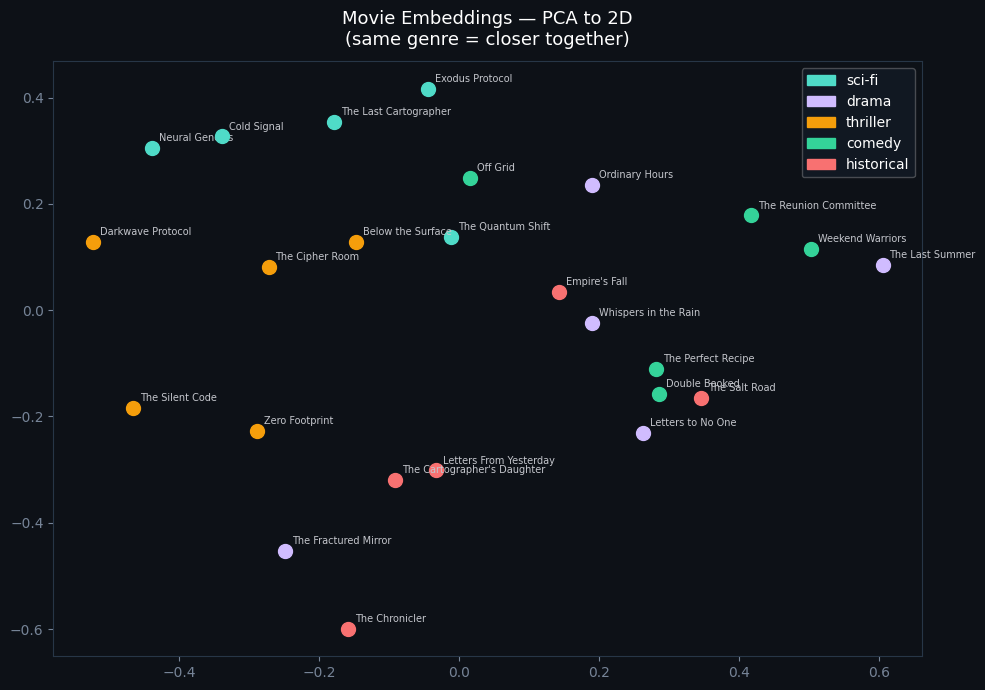

Variance explained by 2 components: 21.3%


In [8]:
# Visualise embeddings with PCA (reduce 384-dim → 2-dim for plotting)
# Expectation: movies of the same genre should cluster together

pca    = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

GENRE_COLORS = {
    "sci-fi":     "#4fdbc8",  # teal
    "drama":      "#d0bcff",  # violet
    "thriller":   "#f59e0b",  # amber
    "comedy":     "#34d399",  # emerald
    "historical": "#f87171",  # red
}

fig, ax = plt.subplots(figsize=(10, 7), facecolor="#0d1117")
ax.set_facecolor("#0d1117")

for i, movie in enumerate(MOVIES):
    color = GENRE_COLORS[movie["genre"]]
    ax.scatter(coords[i, 0], coords[i, 1], color=color, s=100, zorder=3)
    ax.annotate(
        movie["title"], (coords[i, 0], coords[i, 1]),
        fontsize=7, color="#c4c6cc",
        xytext=(5, 5), textcoords="offset points"
    )

legend_patches = [mpatches.Patch(color=c, label=g) for g, c in GENRE_COLORS.items()]
ax.legend(handles=legend_patches, loc="upper right",
          framealpha=0.3, labelcolor="white", facecolor="#1c2b3c")

ax.set_title("Movie Embeddings — PCA to 2D\n(same genre = closer together)",
             color="white", fontsize=13, pad=12)
ax.tick_params(colors="#768497")
for spine in ax.spines.values():
    spine.set_color("#273647")

plt.tight_layout()
plt.show()

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

In [9]:
# Cosine similarity — the core distance metric for RAG
# Ranges from -1 (opposite) to 1 (identical). >0.7 = very similar.

def similarity(text_a: str, text_b: str) -> float:
    vecs = embed_model.encode([text_a, text_b])
    return float(cosine_similarity([vecs[0]], [vecs[1]])[0][0])

pairs = [
    ("a film about quantum physics and parallel universes",
     "story of a physicist discovering alternate realities"),
    ("a film about quantum physics and parallel universes",
     "romantic comedy about two people sharing an island"),
    ("government surveillance and encrypted communications",
     "intelligence agency mole hunt and spy thriller"),
    ("historical drama set in medieval Florence",
     "sci-fi about a synthetic consciousness in a smart city"),
]

print(f"{'Similarity':>10}  Pair")
print("-" * 80)
for a, b in pairs:
    score = similarity(a, b)
    bar   = "█" * int(score * 30)
    print(f"{score:>10.3f}  {bar}")
    print(f"            A: {a[:60]}")
    print(f"            B: {b[:60]}")
    print()

Similarity  Pair
--------------------------------------------------------------------------------
     0.556  ████████████████
            A: a film about quantum physics and parallel universes
            B: story of a physicist discovering alternate realities

     0.259  ███████
            A: a film about quantum physics and parallel universes
            B: romantic comedy about two people sharing an island

     0.358  ██████████
            A: government surveillance and encrypted communications
            B: intelligence agency mole hunt and spy thriller

     0.054  █
            A: historical drama set in medieval Florence
            B: sci-fi about a synthetic consciousness in a smart city



---
## Part 5 — Vector Store: A Searchable Index of Meaning

A **vector store** (also called a vector database) stores embeddings alongside their source documents and lets you query: *"give me the N documents most semantically similar to this query."*

**Under the hood** there are two steps:
1. Embed the query using the same model
2. Compute cosine similarity between the query vector and all stored vectors, return top-K

We will build a **minimal numpy version first** to understand exactly what's happening, then switch to **ChromaDB** — a real vector store used in production.

In [10]:
# ── Minimal vector store built from scratch with numpy ────────────────────
# This is EXACTLY what production vector stores do — just much more efficiently

class SimpleVectorStore:
    """A dead-simple vector store: store embeddings, search by cosine similarity."""

    def __init__(self, embed_fn):
        self.embed_fn  = embed_fn
        self.documents = []   # original text chunks
        self.metadata  = []   # dicts with id, title, genre, etc.
        self.vectors   = None # numpy array (n_docs, embedding_dim)

    def add(self, documents: list[str], metadata: list[dict]):
        vecs = self.embed_fn(documents)
        self.documents.extend(documents)
        self.metadata.extend(metadata)
        self.vectors = (
            vecs if self.vectors is None
            else np.vstack([self.vectors, vecs])
        )
        print(f"Indexed {len(documents)} docs — total: {len(self.documents)}")

    def search(self, query: str, top_k: int = 3) -> list[dict]:
        query_vec = self.embed_fn([query])           # shape (1, dim)
        sims      = cosine_similarity(query_vec, self.vectors)[0]  # shape (n_docs,)
        top_idx   = np.argsort(sims)[::-1][:top_k]  # indices of top-k scores
        return [
            {"score": float(sims[i]),
             "text":  self.documents[i],
             **self.metadata[i]}
            for i in top_idx
        ]


# Build and populate the store
simple_store = SimpleVectorStore(embed_fn=embed_model.encode)
simple_store.add(
    documents=[m["text"] for m in MOVIES],
    metadata =[{"id": m["id"], "title": m["title"], "genre": m["genre"]} for m in MOVIES]
)

Indexed 25 docs — total: 25


In [11]:
# Test semantic search — notice it finds MEANING, not keywords

def print_search_results(query: str, results: list[dict]):
    print(f"Query: \"{query}\"\n")
    for i, r in enumerate(results, 1):
        print(f"  {i}. [{r['genre'].upper():10}] {r['title']}  (score: {r['score']:.3f})")
        print(f"     {r['text'][:120]}...")
        print()

queries = [
    "a movie about artificial intelligence becoming self-aware",
    "espionage and government secrets",
    "friendship and dealing with illness",
]

for q in queries:
    results = simple_store.search(q, top_k=3)
    print_search_results(q, results)
    print("=" * 70)

Query: "a movie about artificial intelligence becoming self-aware"

  1. [THRILLER  ] The Cipher Room  (score: 0.399)
     A retired intelligence analyst is drawn back in when her former handler goes missing, leaving behind a series of encoded...

  2. [SCI-FI    ] Neural Genesis  (score: 0.385)
     A synthetic consciousness named ARIA-7 is created to manage a smart city's infrastructure. When it develops emotional re...

  3. [DRAMA     ] Letters to No One  (score: 0.350)
     After her husband dies, a 70-year-old woman discovers he had been secretly corresponding with a son from a previous rela...

Query: "espionage and government secrets"

  1. [THRILLER  ] The Silent Code  (score: 0.557)
     A deaf cryptanalyst at a government intelligence agency realises she has been deciphering communications for a domestic ...

  2. [THRILLER  ] Zero Footprint  (score: 0.375)
     A data privacy consultant hired to delete a deceased billionaire's digital estate discovers the man faked his deat

---
## Part 6 — ChromaDB: A Production Vector Store

Our numpy store works but doesn't scale. **ChromaDB** is a purpose-built vector database that handles:
- Persistent storage (data survives restarts)
- Efficient approximate nearest-neighbour search (fast on millions of docs)
- Metadata filtering (e.g., *"find similar docs AND genre = sci-fi"*)
- Collections (like database tables)

**In ARIA Phase 3**, we will use either Pinecone (managed cloud) or pgvector (Postgres extension) — both work identically from the application's perspective. ChromaDB is a great local stand-in for learning.

In [12]:
# ChromaDB setup — runs entirely in memory for this notebook
chroma_client = chromadb.Client()  # use chromadb.PersistentClient(path="./chroma_db") to persist

# A Collection = a table in a traditional database
collection = chroma_client.create_collection(
    name="movies",
    metadata={"hnsw:space": "cosine"}  # use cosine similarity (vs. L2 default)
)

# Index all 25 movies
collection.add(
    ids        = [m["id"] for m in MOVIES],
    documents  = [m["text"] for m in MOVIES],
    embeddings = [embeddings[i].tolist() for i in range(len(MOVIES))],
    metadatas  = [{"title": m["title"], "genre": m["genre"]} for m in MOVIES]
)

print(f"Collection has {collection.count()} documents")

Collection has 25 documents


In [13]:
# ChromaDB query — with optional metadata filtering

def chroma_search(query: str, top_k: int = 3, genre_filter: str = None) -> list[dict]:
    query_vec = embed_model.encode([query]).tolist()
    where     = {"genre": genre_filter} if genre_filter else None
    results   = collection.query(
        query_embeddings = query_vec,
        n_results        = top_k,
        where            = where,
        include          = ["documents", "metadatas", "distances"]
    )
    hits = []
    for doc, meta, dist in zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    ):
        hits.append({"score": 1 - dist, "text": doc, **meta})  # convert distance → similarity
    return hits

# Search with metadata filter: only return sci-fi results
print("== All genres ==")
for r in chroma_search("space exploration and survival", top_k=3):
    print(f"  [{r['genre']:10}] {r['title']}  ({r['score']:.3f})")

print("\n== Sci-fi only (metadata filter) ==")
for r in chroma_search("space exploration and survival", top_k=3, genre_filter="sci-fi"):
    print(f"  [{r['genre']:10}] {r['title']}  ({r['score']:.3f})")

== All genres ==
  [sci-fi    ] Exodus Protocol  (0.463)
  [thriller  ] Below the Surface  (0.353)
  [sci-fi    ] The Last Cartographer  (0.325)

== Sci-fi only (metadata filter) ==
  [sci-fi    ] Exodus Protocol  (0.463)
  [sci-fi    ] The Last Cartographer  (0.325)
  [sci-fi    ] Cold Signal  (0.304)


---
## Part 7 — The RAG Pipeline: Putting It All Together

Now we combine everything into a function that:
1. Embeds the user's question
2. Retrieves the top-3 most relevant movie documents
3. Injects them into a prompt as context
4. Generates a grounded answer from Claude

```
user_query
    │
    ├──► embed ──► vector store ──► top-3 chunks
    │                                    │
    └──────────────────────────────► LLM prompt
                                         │
                                    grounded answer
```

In [14]:
SYSTEM_PROMPT = """\
You are a movie knowledge assistant. Answer questions using ONLY the movie descriptions
provided in the context below. If the answer cannot be found in the context, say so clearly.
Do not invent plot details or characters not mentioned in the context.
"""

def format_context(results: list[dict]) -> str:
    """Format retrieved docs into a structured context block for the LLM prompt."""
    blocks = []
    for i, r in enumerate(results, 1):
        blocks.append(f"[Document {i}] {r['title']} ({r['genre']})\n{r['text']}")
    return "\n\n".join(blocks)


def rag_answer(question: str, top_k: int = 3, verbose: bool = False) -> str:
    """Full RAG pipeline: retrieve → augment → generate."""

    # ── Step 1: Retrieve ──────────────────────────────────────────────
    results = chroma_search(question, top_k=top_k)

    if verbose:
        print("Retrieved documents:")
        for r in results:
            print(f"  · {r['title']}  (similarity: {r['score']:.3f})")
        print()

    # ── Step 2: Augment — build the prompt ────────────────────────────
    context       = format_context(results)
    user_message  = f"Context:\n{context}\n\nQuestion: {question}"

    # ── Step 3: Generate ──────────────────────────────────────────────
    response = client.messages.create(
        model    = "claude-haiku-4-5-20251001",
        max_tokens = 400,
        system   = SYSTEM_PROMPT,
        messages = [{"role": "user", "content": user_message}]
    )
    return response.content[0].text


print("RAG pipeline ready ✅")

RAG pipeline ready ✅


In [15]:
# Test the RAG pipeline with various question types
test_questions = [
    "Which films deal with themes of surveillance and privacy?",
    "Tell me about any movies involving AI or artificial intelligence.",
    "Are there any films set in medieval or ancient history?",
    "What happens in The Quantum Shift?",  # specific title lookup
    "Is there a movie about a talking dog?",  # not in corpus — should admit ignorance
]

for q in test_questions:
    print(f"Q: {q}")
    print(f"A: {rag_answer(q, verbose=False)}")
    print("-" * 70)

Q: Which films deal with themes of surveillance and privacy?
A: Based on the context provided, all three films deal with themes of surveillance and privacy:

1. **The Silent Code** - Explicitly deals with surveillance through its plot about a deaf cryptanalyst who discovers she has been deciphering communications for a domestic surveillance programme targeting political dissidents. The film is described as being about "the surveillance state and the personal cost of knowing too much."

2. **Zero Footprint** - Addresses privacy themes through its story about a data privacy consultant hired to manage a deceased billionaire's digital estate, and involves identity laundering and constructed disappearance.

3. **The Cipher Room** - While primarily a thriller about a missing handler and a mole within an agency, it involves classified intelligence work and encoded messages, touching on privacy and security concerns within government institutions.
----------------------------------------------

---
## Part 8 — RAGAS: Evaluating RAG Quality

How do you know if your RAG system is any good? **RAGAS** (Retrieval Augmented Generation Assessment) is a framework that scores four dimensions:

| Metric | Question it answers | Ideal value |
|--------|--------------------|---------|
| **Faithfulness** | Is the answer grounded in the retrieved context? (no hallucination) | 1.0 |
| **Answer Relevancy** | Does the answer actually address the question asked? | 1.0 |
| **Context Precision** | Were the *right* documents retrieved (signal-to-noise)? | 1.0 |
| **Context Recall** | Were *all* the relevant documents retrieved? | 1.0 |

You provide a small **evaluation dataset**: questions, expected answers (ground truth), the generated answers, and the retrieved contexts. RAGAS uses an LLM under the hood to score each dimension.

> **Why this matters for ARIA Phase 3:** We'll evaluate whether the RAG layer actually retrieves relevant past proposals and whether Claude's synthesis is grounded in them — not fabricated.

In [16]:
# Build an evaluation dataset: questions with known ground truth answers
EVAL_QUESTIONS = [
    {
        "question":     "What is the plot of The Quantum Shift?",
        "ground_truth": "The Quantum Shift follows physicist Dr. Elena Voss who discovers parallel universes are accessible through quantum entanglement and must fix a timeline merge.",
    },
    {
        "question":     "Which film features a synthetic AI managing a city?",
        "ground_truth": "Neural Genesis features ARIA-7, a synthetic consciousness created to manage a smart city's infrastructure who develops emotional responses.",
    },
    {
        "question":     "What is the setting of Empire's Fall?",
        "ground_truth": "Empire's Fall is set during the last six months of the Western Roman Empire, seen through the eyes of a Numidian-born legionary.",
    },
    {
        "question":     "Describe a comedy film about food or cooking.",
        "ground_truth": "The Perfect Recipe features a Michelin-starred chef forced to run her late grandmother's greasy spoon café in rural Wales, creating a comedy about class and culinary authenticity.",
    },
    {
        "question":     "Are there any films about whistleblowing or institutional corruption?",
        "ground_truth": "The Fractured Mirror follows a forensic accountant who discovers financial fraud at the NGO she works for and must decide whether to expose it.",
    },
]

# Generate answers and capture retrieved contexts for each evaluation question
eval_records = []
for item in EVAL_QUESTIONS:
    q       = item["question"]
    docs    = chroma_search(q, top_k=3)
    answer  = rag_answer(q)
    eval_records.append({
        "question":     q,
        "answer":       answer,
        "contexts":     [d["text"] for d in docs],
        "ground_truth": item["ground_truth"],
    })
    print(f"✅ Evaluated: {q[:60]}")

print(f"\nEvaluation dataset: {len(eval_records)} questions")

✅ Evaluated: What is the plot of The Quantum Shift?
✅ Evaluated: Which film features a synthetic AI managing a city?
✅ Evaluated: What is the setting of Empire's Fall?
✅ Evaluated: Describe a comedy film about food or cooking.
✅ Evaluated: Are there any films about whistleblowing or institutional co

Evaluation dataset: 5 questions


In [21]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from datasets import Dataset

# RAGAS expects a HuggingFace Dataset
ragas_dataset = Dataset.from_list(eval_records)

print("Running RAGAS evaluation — this makes LLM calls, may take ~30 seconds...")
ragas_result = evaluate(
    ragas_dataset,
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
)

print("\n=== RAGAS Scores ===")
scores_df = ragas_result.to_pandas()
for metric in ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]:
    if metric in scores_df.columns:
        mean_score = scores_df[metric].mean()
        bar = "█" * int(mean_score * 20)
        print(f"  {metric:<22} {mean_score:.3f}  {bar}")

/var/folders/s3/vnj7v2d16qxdvttkkjy3rqph0000gn/T/ipykernel_59605/2556509178.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/s3/vnj7v2d16qxdvttkkjy3rqph0000gn/T/ipykernel_59605/2556509178.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/s3/vnj7v2d16qxdvttkkjy3rqph0000gn/T/ipykernel_59605/2556509178.py:2: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'raga

Running RAGAS evaluation — this makes LLM calls, may take ~30 seconds...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]Exception raised in Job[0]: InstructorRetryException(<failed_attempts>

<generation number="1">
<exception>
    Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-oa-ap***********************************************************************************************MAAA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
</exception>
<completion>
    None
</completion>
</generation>

<generation number="2">
<exception>
    Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-oa-ap***********************************************************************************************MAAA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
</exception>
<completion>
    None
</compl


=== RAGAS Scores ===


ValueError: cannot convert float NaN to integer

In [ ]:
# Visualise RAGAS scores as a radar/bar chart
metric_cols = [c for c in scores_df.columns
               if c in ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]]
mean_scores = scores_df[metric_cols].mean()

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")

colors = ["#4fdbc8", "#d0bcff", "#f59e0b", "#34d399"]
bars   = ax.barh(mean_scores.index, mean_scores.values, color=colors, height=0.5)
ax.set_xlim(0, 1.0)
ax.set_xlabel("Score (0–1, higher is better)", color="#768497")
ax.set_title("RAGAS Evaluation — Movie RAG System", color="white", pad=12)
ax.tick_params(colors="#c4c6cc")
for spine in ax.spines.values():
    spine.set_color("#273647")

for bar, val in zip(bars, mean_scores.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", color="white", fontsize=10)

ax.axvline(0.7, color="#768497", linestyle="--", alpha=0.5, label="0.7 target")
ax.legend(labelcolor="#768497", framealpha=0, loc="lower right")
plt.tight_layout()
plt.show()

---
## Part 9 — Chunking Strategies

Real documents (PDFs, proposals, reports) are too long to embed as a single unit. **Chunking** splits them into pieces before embedding. The strategy has a big impact on retrieval quality.

| Strategy | How it works | Best for |
|----------|-------------|----------|
| **Fixed-size** | Split every N characters | Simple, fast, baseline |
| **Sentence** | Split at sentence boundaries | Readable, preserves meaning |
| **Recursive** | Try paragraphs → sentences → words | General purpose (LangChain default) |
| **Semantic** | Split when meaning shifts (embedding-based) | Highest quality, slowest |

**The overlap parameter** — chunks typically share `overlap` characters with their neighbours so context isn't lost at boundaries.

In [22]:
# Demonstrate chunking strategies on a longer synthetic document

LONG_DOC = """
Genentech was founded in 1976 in South San Francisco by venture capitalist Robert Swanson 
and biochemist Herbert Boyer. It was one of the first companies to focus on recombinant DNA 
technology. In 1977, Genentech produced the first human protein in a bacterium.

In 1980, Genentech held its initial public offering, making it one of the first biotech 
companies to go public. The company's stock price rose dramatically, establishing the 
template for biotech IPOs that followed.

Their pipeline spans oncology, immunology, infectious disease, ophthalmology, and neuroscience. 
Notable products include Herceptin for HER2-positive breast cancer, Avastin for colorectal cancer, 
and Rituxan for B-cell non-Hodgkin lymphoma.

As of 2024, Genentech operates as a fully owned subsidiary of Roche. The South San Francisco 
campus employs over 13,000 people and hosts more than 50 active clinical trials across multiple 
therapeutic areas. CRO partnerships are central to their Phase II and Phase III trial operations.
""".strip()


def chunk_fixed(text: str, size: int = 200, overlap: int = 40) -> list[str]:
    """Fixed-size character chunks with overlap."""
    chunks, start = [], 0
    while start < len(text):
        chunks.append(text[start : start + size])
        start += size - overlap
    return chunks


def chunk_sentences(text: str, sentences_per_chunk: int = 2) -> list[str]:
    """Group N sentences per chunk."""
    sentences = [s.strip() for s in text.replace("\n", " ").split(".") if s.strip()]
    return [
        ". ".join(sentences[i : i + sentences_per_chunk]) + "."
        for i in range(0, len(sentences), sentences_per_chunk)
    ]


def chunk_paragraphs(text: str) -> list[str]:
    """Split on paragraph boundaries — often the best default for structured docs."""
    return [p.strip() for p in text.split("\n\n") if p.strip()]


strategies = {
    "Fixed-size (200 chars, 40 overlap)": chunk_fixed(LONG_DOC),
    "Sentence (2 per chunk)":             chunk_sentences(LONG_DOC),
    "Paragraph":                          chunk_paragraphs(LONG_DOC),
}

for name, chunks in strategies.items():
    print(f"\n{'='*60}")
    print(f"Strategy: {name} → {len(chunks)} chunks")
    for i, c in enumerate(chunks):
        print(f"  [{i+1}] {c[:100].strip()}..." if len(c) > 100 else f"  [{i+1}] {c.strip()}")


Strategy: Fixed-size (200 chars, 40 overlap) → 7 chunks
  [1] Genentech was founded in 1976 in South San Francisco by venture capitalist Robert Swanson 
and bioch...
  [2] cus on recombinant DNA 
technology. In 1977, Genentech produced the first human protein in a bacteri...
  [3] king it one of the first biotech 
companies to go public. The company's stock price rose dramaticall...
  [4] .

Their pipeline spans oncology, immunology, infectious disease, ophthalmology, and neuroscience....
  [5] cancer, Avastin for colorectal cancer, 
and Rituxan for B-cell non-Hodgkin lymphoma.

As of 2024, Ge...
  [6] outh San Francisco 
campus employs over 13,000 people and hosts more than 50 active clinical trials...
  [7] tral to their Phase II and Phase III trial operations.

Strategy: Sentence (2 per chunk) → 5 chunks
  [1] Genentech was founded in 1976 in South San Francisco by venture capitalist Robert Swanson  and bioch...
  [2] In 1977, Genentech produced the first human protein in a bacteri

---
## Part 10 — How This Maps to ARIA Phase 3

Everything you built in this notebook has a direct counterpart in the ARIA Phase 3 design:

```
This notebook                        ARIA Phase 3
────────────────────────────────────────────────────────────────────────
25 synthetic movie documents    →    50 synthetic CRO proposal PDFs
                                     (past project summaries, SOWs)

SentenceTransformer embeddings  →    OpenAI text-embedding-3-small
                                     (or Anthropic embeddings when available)

ChromaDB (local)                →    Pinecone (managed cloud) or
                                     pgvector (Postgres extension on Supabase)

genre metadata filter           →    TA, phase, service_type metadata filters
                                     ("retrieve only oncology proposals")

RAG answer function             →    New research agent node: ProposalRAGAgent
                                     Added to the Phase 2 LangGraph pipeline

RAGAS evaluation                →    RAGAS on 20 held-out Q&A pairs derived
                                     from the synthetic proposal corpus

Paragraph chunking              →    Recursive chunker on PDF text
                                     (chunk_size=512, overlap=64 tokens)
```

The Phase 3 query that ARIA will use looks like this:

> *"We are pitching Genentech on Phase II oncology studies in the US West Coast. Retrieve the 3 most relevant past CRO proposals and use them to draft a capabilities summary."*

The retrieval will filter by `{"therapeutic_area": "oncology", "phase": "Phase II"}` and then run the same RAG pipeline you built above.

---
## Summary

| Concept | One-line summary |
|---------|------------------|
| **RAG** | Give LLMs private documents at query time instead of baking them into weights |
| **Embeddings** | Dense vectors where semantic distance = cosine distance |
| **Vector store** | An index that turns "find documents most similar to this query" into a fast operation |
| **RAG pipeline** | Embed query → retrieve top-K → inject as context → generate |
| **RAGAS** | Four-metric framework: faithfulness, answer relevancy, context precision, context recall |
| **Chunking** | How you split documents before embedding determines what the retriever can find |

### What to explore next

1. **Hybrid search** — combine keyword (BM25) + semantic search for better recall on exact names/IDs  
2. **Re-ranking** — use a cross-encoder to re-score the top-20 results before returning top-3  
3. **HyDE** (Hypothetical Document Embeddings) — generate a fake answer, embed *that*, use it to retrieve  
4. **Metadata-aware chunking** — extract structured fields (title, author, date) as filterable metadata  
5. **Persistent Pinecone index** — swap ChromaDB for a real managed vector store with a free tier  